In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
dataset_path = Path("../dataset/plantvillage dataset/color")

print(dataset_path.exists())

True


In [3]:
img_height = 224
img_width = 224
batch_size = 16

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.shuffle(1000).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [6]:
model = models.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(38, activation="softmax")
])

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "../model/best_cnn.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

In [10]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20


c:\Users\LENOVO\OneDrive\Desktop\SmartAgroAI\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1483s 542ms/step - accuracy: 0.5987 - loss: 1.4026 - val_accuracy: 0.6524 - val_loss: 1.2956
Epoch 2/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 908s 330ms/step - accuracy: 0.7819 - loss: 0.7072 - val_accuracy: 0.7231 - val_loss: 1.1183
Epoch 3/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 960s 350ms/step - accuracy: 0.8446 - loss: 0.4973 - val_accuracy: 0.7348 - val_loss: 0.9955
Epoch 4/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1015s 369ms/step - accuracy: 0.8775 - loss: 0.3878 - val_accuracy: 0.8424 - val_loss: 0.5205
Epoch 5/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1016s 370ms/step - accuracy: 0.8954 - loss: 0.3282 - val_accuracy: 0.8131 - val_loss: 0.5960
Epoch 6/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1008s 366ms/step - accuracy: 0.9133 - loss: 0.2747 - val_accuracy: 0.7563 - val_loss: 1.1592
Epoch 7/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1019s 370ms/step - accuracy: 0.9214 - loss: 0.2469 - val_accuracy: 0.8851 - val_loss: 0.4335
Epoch 8/20
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 1084s 393ms/step - accurac

In [11]:
from tensorflow.keras.models import load_model

best_model = load_model("../model/best_cnn.keras")

In [12]:
loss, accuracy = best_model.evaluate(validation_dataset)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

679/679 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.9117 - loss: 0.2690
Validation Loss: 0.2690
Validation Accuracy: 0.9117


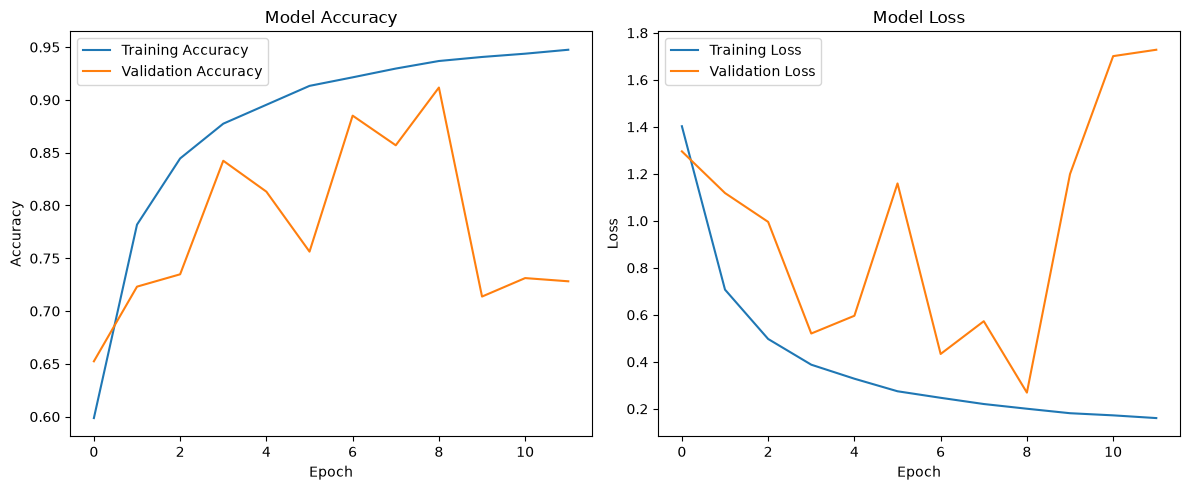

In [13]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
temp_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32
)

class_names = temp_dataset.class_names

print("Number of classes:", len(class_names))
print(class_names)

Found 54305 files belonging to 38 classes.
Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'To

In [16]:
import json

with open("../model/class_names.json", "w") as f:
    json.dump(class_names, f)

print("✅ class_names.json saved successfully!")

✅ class_names.json saved successfully!


In [17]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [18]:
model = load_model("../model/best_cnn.keras")

with open("../model/class_names.json", "r") as f:
    class_names = json.load(f)

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [19]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    print(f"Prediction : {predicted_class}")
    print(f"Confidence : {confidence:.2f}%")

    return predicted_class, confidence

In [20]:
test_image = "../dataset/plantvillage dataset/color/Tomato___Early_blight/0ba3d536-8732-4ea1-b3e1-a1be86e5dc6a___RS_Erly.B 9499.jpg"

predict_image(test_image)

Prediction : Tomato___Early_blight
Confidence : 76.25%


('Tomato___Early_blight', np.float32(76.246414))

In [25]:
from IPython.display import display
import ipywidgets as widgets

upload = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(upload)

FileUpload(value=(), accept='image/*', description='Upload')

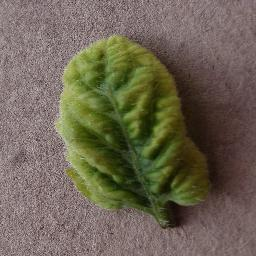


🌿 Prediction : Tomato___Tomato_Yellow_Leaf_Curl_Virus
🎯 Confidence : 97.41%


('Tomato___Tomato_Yellow_Leaf_Curl_Virus', 97.40502166748047)

In [38]:
import io
import numpy as np
from PIL import Image
from IPython.display import display

def predict_uploaded_image(upload_widget):

    if len(upload_widget.value) == 0:
        print("Please upload an image first.")
        return

    # Get uploaded file
    uploaded = upload_widget.value[0]

    image_bytes = uploaded["content"]

    # Convert memoryview to bytes
    if isinstance(image_bytes, memoryview):
        image_bytes = image_bytes.tobytes()

    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")

    # Show image
    display(img)

    # Preprocess
    img = img.resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)

    predicted_index = np.argmax(prediction)
    confidence = float(np.max(prediction) * 100)

    predicted_class = class_names[predicted_index]

    print(f"\n🌿 Prediction : {predicted_class}")
    print(f"🎯 Confidence : {confidence:.2f}%")

    return predicted_class, confidence

predict_uploaded_image(upload)

In [39]:
print(type(upload.value))
print(upload.value)

<class 'tuple'>
({'name': '0ae9ff61-7285-4683-897e-a9703ead6307___YLCV_NREC 2199.JPG', 'type': 'image/jpeg', 'size': 15388, 'content': <memory at 0x000002A78141B880>, 'last_modified': datetime.datetime(2026, 8, 1, 12, 2, 24, tzinfo=datetime.timezone.utc)},)
